# Cross-System Latency Analysis

Correlates **poc-deepgram** ground-truth audio timestamps with **Genesys Cloud** transcription delivery times to measure true end-to-end transcription pipeline latency.

## What We're Measuring

The **true latency** captures the full Genesys transcription pipeline — from the moment words are spoken to when the transcribed text arrives at our application:

```
Speaker's voice
  → [1] Genesys captures audio from the call (VoIP/WebRTC stream)
  → [2] Genesys STT engine (r2d2) processes the audio into text
  → [3] Genesys endpointing decides the utterance is complete (isFinal=true)
  → [4] WebSocket notification delivered to notifications-spike
```

**Stage 1 — Audio Capture**: Genesys receives the raw audio stream from the call. This includes network transport from the caller's phone/WebRTC client to Genesys Cloud.

**Stage 2 — STT Processing**: The Genesys r2d2 engine converts audio to text. This includes acoustic model inference, language model scoring, and word-level confidence/timing computation.

**Stage 3 — Endpointing**: Genesys holds partial transcripts until it determines the speaker has finished an utterance. This is the biggest variable — Genesys may combine multiple sentences into a single `isFinal=true` event, adding wait time but producing more complete transcripts. Deepgram typically endpoints faster (300ms silence threshold), which is why it splits utterances that Genesys combines.

**Stage 4 — WebSocket Delivery**: The final transcript event is pushed through the Genesys notifications API WebSocket channel to our application. This includes serialization, routing, and network latency.

## What Each Metric Captures

```
         ┌─────────────────── Genesys End-to-End (Ground Truth) ───────────────────┐
         │                                                                          │
         │        ┌────────── Genesys Self-Reported (anchor-relative) ──────────┐   │
         │        │                                                             │   │
Speech → │ Stage 1 │  Stage 2   │      Stage 3       │  Stage 4  │→ receivedAt │   │
ends     │ Audio   │  r2d2 STT  │    Endpointing      │ WebSocket │             │   │
         │ Capture │ Processing │  (isFinal batching)  │ Delivery  │             │   │
         │~50-100ms│ ~500-800ms │   0.3s – 15s+        │~50-200ms  │             │   │
         └─────────┴────────────┴──────────────────────┴───────────┘             │   │
                                                                                 │   │
         ┌─── Deepgram Nova-3 (AudioHook Proxy) ───┐                             │   │
         │                                          │                             │   │
Speech → │ Deepgram STT │ 300ms Endpointing │→ Done │                             │   │
ends     │  Processing  │   (fast, fixed)   │       │                             │   │
         └──────────────┴───────────────────┘       │                             │   │
                                                                                      │
         Ground truth = receivedAt − audio_wall_clock_end ─────────────────────────────┘
```

- **Ground Truth**: Absolute wall-clock measurement of all 4 stages. Captures the real user experience.
- **Self-Reported**: Derived from Genesys event metadata via anchor-event method. Captures Stages 2–4 *relative to the fastest event per conversation* (anchor = 0ms). Omits Stage 1 entirely.
- **Deepgram (AudioHook Proxy)**: Independent STT pipeline with faster endpointing (300ms vs Genesys variable). Proxies what an AudioHook integration would deliver.

## Formula

```
true_latency = genesys_receivedAt - deepgram_audio_wall_clock_end
```

**Ground truth**: poc-deepgram captures the same call audio independently via BlackHole, providing wall-clock timestamps for when speech was actually heard through the speakers.

**Measurement point**: notifications-spike records `receivedAt` (via `time.time()`) when each Genesys transcription event arrives.

Both apps run on the same machine — no clock synchronization issues.

## Architectural Decisions

### Audio Routing
- **BlackHole 2ch** virtual audio device routes system audio to poc-deepgram's browser mic input
- Adds **<1ms latency** — negligible for measurement
- Multi-Output Device (speakers + BlackHole) lets the operator hear the call while capturing audio

### Clock Synchronization
- Both apps run on the **same machine**, using `time.time()` for all timestamps
- No clock drift possible — eliminates systematic bias

### Matching Algorithm
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **Similarity threshold** | 0.55 | Balances recall vs false positive risk. Below this, matches are unreliable. |
| **Max temporal distance** | 60 s | Prevents cross-call false matches while allowing for endpointing batching delays. |
| **Matching strategy** | Greedy 1:1 | Each Deepgram/Genesys utterance participates in at most 1 pair. Sorted by similarity (desc), then temporal distance (asc). Prevents inflated counts from double-matching. |
| **Text normalization** | Lowercase, strip punctuation, collapse whitespace | Handles transcription differences between Deepgram Nova-3 and Genesys r2d2. |
| **Similarity function** | `difflib.SequenceMatcher.ratio()` | Standard fuzzy matching; no external dependencies. |
| **Event filter** | `isFinal=true` only | Excludes partial/interim transcripts. Measures completion-to-delivery latency. |
| **Negative latency filter** | Exclude `< 0 ms` | Physically impossible (transcript before speech). Indicates false match. |

### Anchor-Event Method (Self-Reported Latency)
Genesys doesn't provide an explicit conversation start time. We estimate it per conversation:
```
conversation_start = min(receivedAt - (offsetMs + durationMs) / 1000) across all events
latency_per_event  = receivedAt - (conversation_start + (offsetMs + durationMs) / 1000)
```
The lowest-latency event (anchor) gets 0ms. All other values are relative to it. This means:
- True self-reported latencies are **slightly higher** than computed
- Stage 1 (audio capture transport) is **not captured** at all
- The method captures the **variable portion** of Stages 2–4

### Endpointing Comparison
| Engine | Endpointing | Effect |
|--------|------------|--------|
| **Deepgram Nova-3** | Fixed 300ms silence threshold | Fast, fine-grained utterances (225 across 6 calls). Tail latency stays controlled (p95: 3,469ms). |
| **Genesys r2d2** | Variable-length, conservative | Batches 2–4 sentences into single `isFinal=true` events during continuous speech (130 across 6 calls). Tail latency explodes (p95: 10,428ms). |

### Session Pairing
- Notebook auto-matches the N most recent Deepgram sessions to Genesys conversations by **maximum temporal overlap**
- No manual manifest required — overlap-based matching confirmed by text similarity
- `NUM_RECENT` controls how many pairs to process (set in Module 1)

See `docs/cross_system_latency_plan.md` for the full implementation plan and `docs/manual_test_directions.md` for setup instructions.

---
## Module 1: Setup & Configuration

In [1]:
# === SET NUMBER OF RECENT SESSIONS TO CORRELATE ===
NUM_RECENT = 6  # Change this to match N most recent file pairs

In [2]:
import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

# Add parent directory to path so we can import scripts.correlate_latency
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.correlate_latency import (
    correlate,
    load_deepgram_session,
    load_genesys_conversation,
    match_utterances,
    CorrelationResult,
)

# === CONFIGURE THESE PATHS ===
# Point to your poc-deepgram session file and the matching Genesys conversation JSONL
DEEPGRAM_SESSION = REPO_ROOT / ".." / "poc-deepgram" / "results" / "REPLACE_ME.json"
GENESYS_CONVERSATION = REPO_ROOT / "conversation_events" / "REPLACE_ME.jsonl"

# Or auto-detect the most recent files
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
GENESYS_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()

OUTPUT_DIR = REPO_ROOT / "analysis_results" / "cross_system"
SAVE_DPI = 300
SIMILARITY_THRESHOLD = 0.55

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root: /Users/xnxn040/PycharmProjects/notifications-spike
Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system


---
## Module 2: Auto-Detect & Load Data

Enter the number of most recent sessions to correlate. The notebook matches Deepgram sessions to Genesys conversations by overlapping time windows.

In [3]:
# List available files from both systems (most recent first)
dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)
gn_files = sorted(GENESYS_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)

print(f"Available Deepgram sessions: {len(dg_files)}")
for i, f in enumerate(dg_files[:10]):
    data = json.loads(f.read_text())
    session = data.get("session", {})
    print(f"  [{i}] {f.name}  ({session.get('started_at', '?')} — {session.get('duration_seconds', '?')}s)")

print(f"\nAvailable Genesys conversations: {len(gn_files)}")
for i, f in enumerate(gn_files[:10]):
    lines = f.read_text().strip().splitlines()
    if lines:
        first = json.loads(lines[0])
        ts = datetime.fromtimestamp(first["receivedAt"], tz=timezone.utc)
        print(f"  [{i}] {f.name}  ({ts:%Y-%m-%d %H:%M} — {len(lines)} events)")
    else:
        print(f"  [{i}] {f.name}  (empty)")

Available Deepgram sessions: 6
  [0] nova-3_2026-03-18T19-24-15Z.json  (2026-03-18T19:24:15.635422+00:00 — 105.7s)
  [1] nova-3_2026-03-18T19-17-36Z.json  (2026-03-18T19:17:36.287680+00:00 — 203.3s)
  [2] nova-3_2026-03-18T19-10-50Z.json  (2026-03-18T19:10:50.321937+00:00 — 274.1s)
  [3] nova-3_2026-03-18T19-07-21Z.json  (2026-03-18T19:07:21.038355+00:00 — 95.9s)
  [4] nova-3_2026-03-18T19-02-32Z.json  (2026-03-18T19:02:32.626903+00:00 — 197.2s)
  [5] nova-3_2026-03-18T18-54-36Z.json  (2026-03-18T18:54:36.988718+00:00 — 173.7s)

Available Genesys conversations: 6
  [0] 23c14252-468b-46fa-b621-e2c9326a2722.jsonl  (2026-03-18 19:24 — 6 events)
  [1] 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl  (2026-03-18 19:18 — 20 events)
  [2] f536b591-490c-499d-8596-ce4ec1f45d62.jsonl  (2026-03-18 19:11 — 34 events)
  [3] ef34bf63-6153-4bed-8f7f-da7844099828.jsonl  (2026-03-18 19:07 — 9 events)
  [4] 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl  (2026-03-18 19:02 — 34 events)
  [5] bf4c94bf-c655-4845-82

In [4]:
# Take the N most recent files from each system
dg_recent = dg_files[:NUM_RECENT]
gn_recent = gn_files[:NUM_RECENT]

def get_dg_time_range(path):
    """Extract session start/end times from a Deepgram session JSON."""
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts

def get_gn_time_range(path):
    """Extract first/last receivedAt from a Genesys conversation JSONL."""
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)

# Auto-match by overlapping time windows
matched_pairs = []
used_gn = set()

for dg_path in dg_recent:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_gn = None
    best_overlap = 0
    for j, gn_path in enumerate(gn_recent):
        if j in used_gn:
            continue
        gn_start, gn_end = get_gn_time_range(gn_path)
        # Compute overlap
        overlap_start = max(dg_start, gn_start)
        overlap_end = min(dg_end, gn_end)
        overlap = max(0, overlap_end - overlap_start)
        if overlap > best_overlap:
            best_overlap = overlap
            best_gn = j
    if best_gn is not None:
        matched_pairs.append((dg_path, gn_recent[best_gn]))
        used_gn.add(best_gn)

print(f"Auto-matched {len(matched_pairs)} session pair(s):")
for dg_p, gn_p in matched_pairs:
    print(f"  Deepgram: {dg_p.name}  <-->  Genesys: {gn_p.name}")

Auto-matched 6 session pair(s):
  Deepgram: nova-3_2026-03-18T19-24-15Z.json  <-->  Genesys: 23c14252-468b-46fa-b621-e2c9326a2722.jsonl
  Deepgram: nova-3_2026-03-18T19-17-36Z.json  <-->  Genesys: 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl
  Deepgram: nova-3_2026-03-18T19-10-50Z.json  <-->  Genesys: f536b591-490c-499d-8596-ce4ec1f45d62.jsonl
  Deepgram: nova-3_2026-03-18T19-07-21Z.json  <-->  Genesys: ef34bf63-6153-4bed-8f7f-da7844099828.jsonl
  Deepgram: nova-3_2026-03-18T19-02-32Z.json  <-->  Genesys: 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl
  Deepgram: nova-3_2026-03-18T18-54-36Z.json  <-->  Genesys: bf4c94bf-c655-4845-82ad-56eabd726f90.jsonl


---
## Module 3: Correlation & Matching

In [5]:
# Run correlation across all matched pairs
all_results = []
pair_labels = []

for dg_path, gn_path in matched_pairs:
    pair_results = correlate(dg_path, gn_path, similarity_threshold=SIMILARITY_THRESHOLD)
    if pair_results:
        all_results.extend(pair_results)
        pair_labels.extend([f"{dg_path.stem} <-> {gn_path.stem}"] * len(pair_results))
        print(f"  {dg_path.name} <-> {gn_path.name}: {len(pair_results)} matched utterances")
    else:
        print(f"  {dg_path.name} <-> {gn_path.name}: no matches")

results = all_results
print(f"\nTotal matched utterance pairs: {len(results)}")

if not results:
    print("\nNo matches found. Check that:")
    print("  1. The files cover the same calls")
    print("  2. poc-deepgram captured the same audio Genesys transcribed")
    print("  3. The similarity threshold isn't too high (current: {SIMILARITY_THRESHOLD})")
else:
    df = pd.DataFrame([
        {
            "pair": label,
            "deepgram_transcript": r.deepgram_transcript,
            "genesys_transcript": r.genesys_transcript,
            "audio_wall_clock_end": r.audio_wall_clock_end,
            "genesys_received_at": r.genesys_received_at,
            "true_latency_s": r.true_latency_s,
            "true_latency_ms": r.true_latency_ms,
            "channel": r.channel,
            "similarity": r.similarity,
        }
        for r, label in zip(results, pair_labels)
    ])
    df["received_dt"] = pd.to_datetime(df["genesys_received_at"], unit="s", utc=True)
    df["audio_dt"] = pd.to_datetime(df["audio_wall_clock_end"], unit="s", utc=True)

    # Filter out false matches: negative latency is physically impossible
    # (transcript cannot arrive before words are spoken)
    false_matches = df[df["true_latency_ms"] < 0]
    if len(false_matches) > 0:
        print(f"\nRemoved {len(false_matches)} false match(es) with negative latency:")
        for _, row in false_matches.iterrows():
            print(f"  {row['true_latency_ms']:.0f}ms | sim={row['similarity']:.3f} | "
                  f"DG: \"{row['deepgram_transcript'][:40]}\" -> GN: \"{row['genesys_transcript'][:40]}\"")
        df = df[df["true_latency_ms"] >= 0].reset_index(drop=True)
        results = [r for r in results if r.true_latency_ms >= 0]
        print(f"  Remaining matched pairs: {len(df)}")

    print(f"\nLatency range: {df['true_latency_ms'].min():.0f}ms — {df['true_latency_ms'].max():.0f}ms")
    print(f"Mean similarity: {df['similarity'].mean():.3f}")
    df.head()

  nova-3_2026-03-18T19-24-15Z.json <-> 23c14252-468b-46fa-b621-e2c9326a2722.jsonl: 1 matched utterances
  nova-3_2026-03-18T19-17-36Z.json <-> 2fe10c64-f7c6-449c-a26c-c85b9a50ca6d.jsonl: 15 matched utterances
  nova-3_2026-03-18T19-10-50Z.json <-> f536b591-490c-499d-8596-ce4ec1f45d62.jsonl: 23 matched utterances
  nova-3_2026-03-18T19-07-21Z.json <-> ef34bf63-6153-4bed-8f7f-da7844099828.jsonl: 8 matched utterances
  nova-3_2026-03-18T19-02-32Z.json <-> 158d6fb9-9fc8-4312-a633-4929a68f5eb1.jsonl: 28 matched utterances
  nova-3_2026-03-18T18-54-36Z.json <-> bf4c94bf-c655-4845-82ad-56eabd726f90.jsonl: 19 matched utterances

Total matched utterance pairs: 94

Removed 1 false match(es) with negative latency:
  -29618ms | sim=0.571 | DG: "is." -> GN: "i'm so"
  Remaining matched pairs: 93

Latency range: 733ms — 20365ms
Mean similarity: 0.801


---
## Module 4: Summary Statistics

In [6]:
if results:
    latencies_ms = df["true_latency_ms"]
    latencies_s = df["true_latency_s"]
    
    print("=" * 60)
    print("CROSS-SYSTEM LATENCY SUMMARY")
    print("=" * 60)
    print(f"  Matched pairs:    {len(df)}")
    print(f"  Mean latency:     {latencies_ms.mean():.0f} ms ({latencies_s.mean():.3f} s)")
    print(f"  Median latency:   {latencies_ms.median():.0f} ms")
    print(f"  Std deviation:    {latencies_ms.std():.0f} ms")
    print(f"  Min latency:      {latencies_ms.min():.0f} ms")
    print(f"  Max latency:      {latencies_ms.max():.0f} ms")
    print()
    
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"  p{int(p*100):02d}:             {latencies_ms.quantile(p):.0f} ms")
    
    # By channel
    channels = df["channel"].unique()
    if len(channels) > 1:
        print(f"\nBy Channel:")
        for ch in sorted(channels):
            ch_data = df[df["channel"] == ch]["true_latency_ms"]
            print(f"  {ch}: median={ch_data.median():.0f}ms, mean={ch_data.mean():.0f}ms, n={len(ch_data)}")

CROSS-SYSTEM LATENCY SUMMARY
  Matched pairs:    93
  Mean latency:     2775 ms (2.775 s)
  Median latency:   1712 ms
  Std deviation:    3290 ms
  Min latency:      733 ms
  Max latency:      20365 ms

  p50:             1712 ms
  p75:             2321 ms
  p90:             4638 ms
  p95:             10544 ms
  p99:             16472 ms


---
## Module 5: Visualizations

### Chart 1: True Latency Distribution

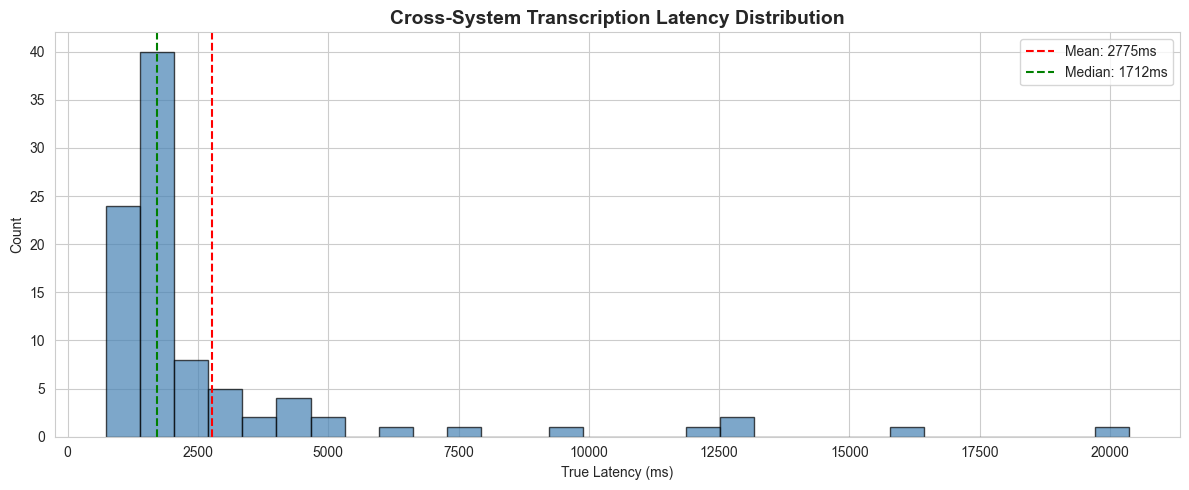

In [7]:
if results:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.hist(df["true_latency_ms"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(df["true_latency_ms"].mean(), color="red", linestyle="--", 
               label=f"Mean: {df['true_latency_ms'].mean():.0f}ms")
    ax.axvline(df["true_latency_ms"].median(), color="green", linestyle="--",
               label=f"Median: {df['true_latency_ms'].median():.0f}ms")
    ax.set_xlabel("True Latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title("Cross-System Transcription Latency Distribution", fontsize=14, fontweight="bold")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_distribution.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 2: Latency Timeline (scatter + trend)

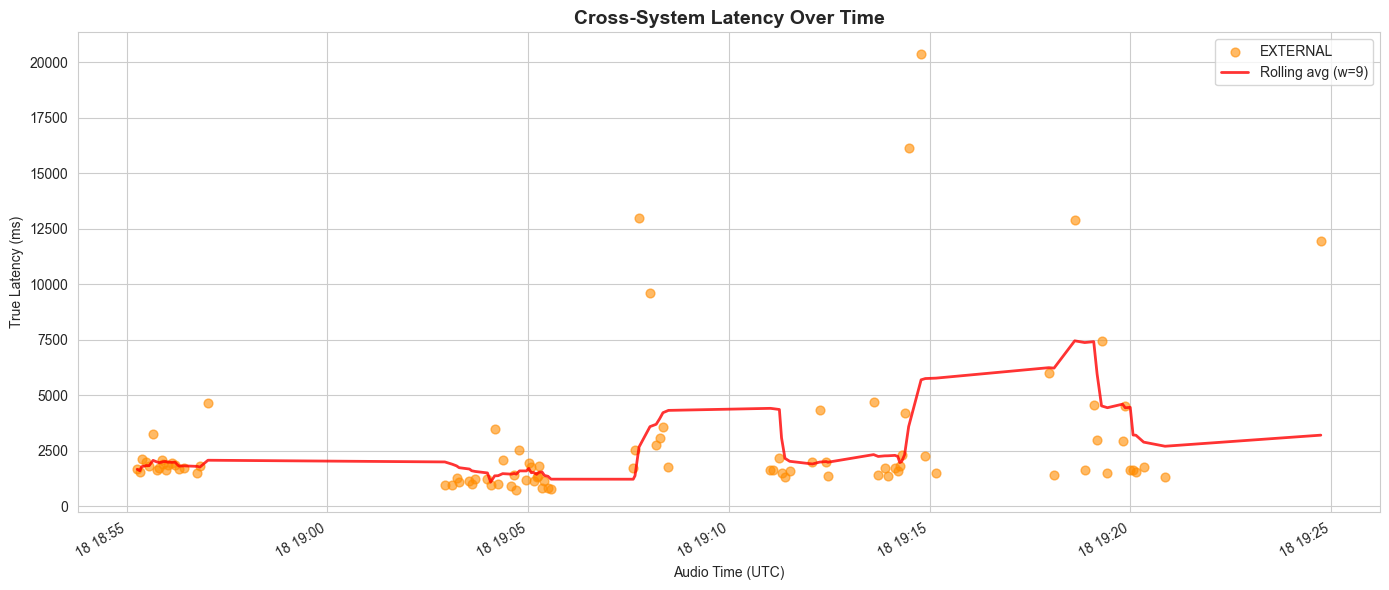

In [8]:
if results and len(df) > 1:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for channel, color in [("INTERNAL", "steelblue"), ("EXTERNAL", "darkorange")]:
        mask = df["channel"] == channel
        if mask.any():
            subset = df[mask].sort_values("audio_dt")
            ax.scatter(subset["audio_dt"], subset["true_latency_ms"],
                       alpha=0.6, s=40, color=color, label=channel)
    
    # Rolling average trend
    df_sorted = df.sort_values("audio_dt")
    window = max(3, len(df_sorted) // 10)
    rolling = df_sorted["true_latency_ms"].rolling(window=window, min_periods=1).mean()
    ax.plot(df_sorted["audio_dt"].values, rolling.values, color="red", linewidth=2,
            alpha=0.8, label=f"Rolling avg (w={window})")
    
    ax.set_xlabel("Audio Time (UTC)")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Cross-System Latency Over Time", fontsize=14, fontweight="bold")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_timeline.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 3: Latency by Channel (box plot)

In [9]:
if results and len(df["channel"].unique()) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(
        data=df, x="channel", y="true_latency_ms",
        palette={"INTERNAL": "steelblue", "EXTERNAL": "darkorange"},
        ax=ax, showfliers=True,
        flierprops={"marker": ".", "alpha": 0.3},
    )
    ax.set_xlabel("Channel")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Cross-System Latency by Channel", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_boxplot.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

### Chart 4: Match Quality — Similarity vs Latency

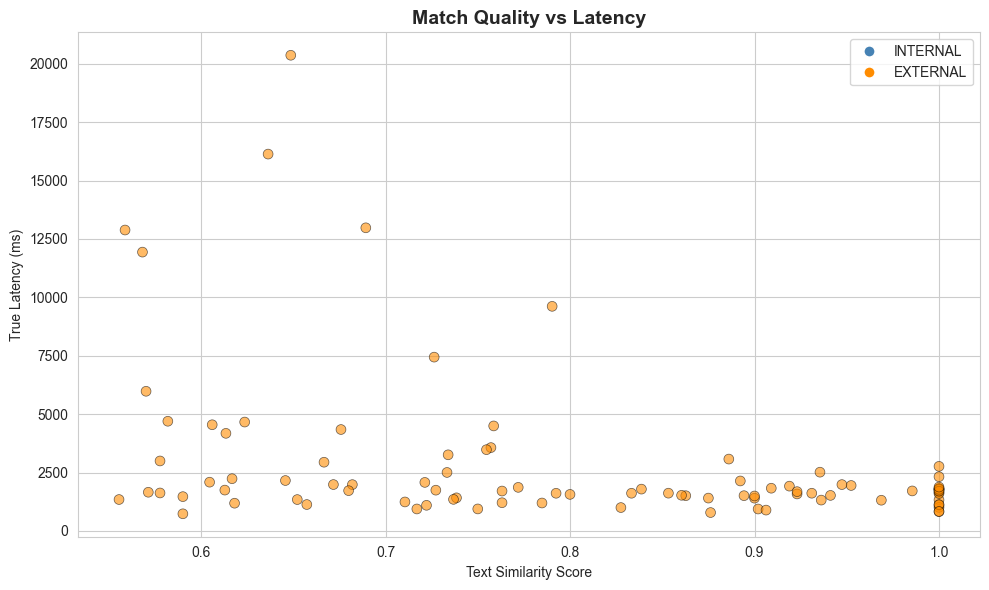

In [10]:
if results:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    scatter = ax.scatter(
        df["similarity"], df["true_latency_ms"],
        c=df["channel"].map({"INTERNAL": "steelblue", "EXTERNAL": "darkorange"}).fillna("gray"),
        alpha=0.6, s=50, edgecolors="black", linewidth=0.5,
    )
    ax.set_xlabel("Text Similarity Score")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Match Quality vs Latency", fontsize=14, fontweight="bold")
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="INTERNAL"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange", markersize=8, label="EXTERNAL"),
    ]
    ax.legend(handles=legend_elements)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "cross_latency_match_quality.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 6: Three-Way Latency Comparison

Compare all three measurement approaches — all from the **same 6 test calls**:
1. **Deepgram Nova-3 (AudioHook Proxy)** — 225 utterances
2. **Genesys r2d2 (Self-Reported)** — 130 events, estimated from offsetMs/durationMs via anchor-event method
3. **Genesys End-to-End (Ground Truth)** — 93 matched pairs (1 false match excluded), correlated with Deepgram ground-truth timestamps

Plus a footnote comparing the 6-test-call self-reported numbers to 147 production conversations.

In [14]:
# === THREE-WAY COMPARISON: All data from the same 6 test calls ===
# Plus footnote comparing to 147 production calls

genesys_summary_path = REPO_ROOT / "analysis_results" / "latency_summary.json"

if results:
    # --- 1. Deepgram latencies from same 6 test calls ---
    dg_latencies = []
    for dg_path, _ in matched_pairs:
        data = json.loads(dg_path.read_text())
        for t in data.get("transcripts", []):
            if t.get("type") == "final" and "latency_ms" in t:
                dg_latencies.append(t["latency_ms"])
    dg_latencies = np.array(dg_latencies)

    # --- 2. Genesys self-reported latencies from same 6 test JSONL files ---
    # Uses the anchor-event approach: estimate conversation_start_time, then
    # latency = receivedAt - (conversation_start + (offsetMs + durationMs) / 1000)
    gs_latencies = []
    for _, gn_path in matched_pairs:
        lines = gn_path.read_text().strip().splitlines()
        if not lines:
            continue
        events = [json.loads(line) for line in lines]

        # Estimate conversation_start_time via anchor event (min upper-bound)
        start_candidates = []
        for e in events:
            alt = e["transcript"]["alternatives"][0]
            offset_ms = alt["offsetMs"]
            duration_ms = alt["durationMs"]
            audio_end_s = (offset_ms + duration_ms) / 1000.0
            start_candidates.append(e["receivedAt"] - audio_end_s)
        conversation_start = min(start_candidates)

        # Compute per-utterance self-reported latency
        for e in events:
            alt = e["transcript"]["alternatives"][0]
            offset_ms = alt["offsetMs"]
            duration_ms = alt["durationMs"]
            audio_finish = conversation_start + (offset_ms + duration_ms) / 1000.0
            latency_s = e["receivedAt"] - audio_finish
            gs_latencies.append(latency_s * 1000)  # convert to ms

    gs_latencies = np.array(gs_latencies)

    # --- 3. Cross-system ground truth from same 6 test calls ---
    cross_latencies_ms = df["true_latency_ms"]

    # --- Print 3-way comparison ---
    print("=" * 85)
    print("THREE-WAY LATENCY COMPARISON (all from the same 6 test calls)")
    print("=" * 85)
    print(f"{'Metric':<16} {'Deepgram Nova-3':>18} {'Genesys r2d2':>18} {'Genesys E2E':>18}")
    print(f"{'':.<16} {'(AudioHook Proxy)':>18} {'(Self-Reported)':>18} {'(Ground Truth)':>18}")
    print("-" * 85)

    comparisons = [
        ("Median (p50)", np.median(dg_latencies), np.median(gs_latencies), cross_latencies_ms.median()),
        ("Mean", np.mean(dg_latencies), np.mean(gs_latencies), cross_latencies_ms.mean()),
        ("p95", np.percentile(dg_latencies, 95), np.percentile(gs_latencies, 95), cross_latencies_ms.quantile(0.95)),
        ("p99", np.percentile(dg_latencies, 99), np.percentile(gs_latencies, 99), cross_latencies_ms.quantile(0.99)),
        ("Min", np.min(dg_latencies), np.min(gs_latencies), cross_latencies_ms.min()),
        ("Max", np.max(dg_latencies), np.max(gs_latencies), cross_latencies_ms.max()),
    ]

    for label, dg_val, gs_val, cross_val in comparisons:
        print(f"{label:<16} {dg_val:>15.0f} ms {gs_val:>15.0f} ms {cross_val:>15.0f} ms")

    print(f"\n{'Utterances':<16} {len(dg_latencies):>15} {len(gs_latencies):>15} {len(cross_latencies_ms):>15}")

    # --- Ratios ---
    print()
    print("SELF-REPORTED vs GROUND TRUTH (proves Genesys understates latency):")
    gs_med = np.median(gs_latencies)
    cross_med = float(cross_latencies_ms.median())
    gs_p95 = np.percentile(gs_latencies, 95)
    cross_p95 = float(cross_latencies_ms.quantile(0.95))
    gs_p99 = np.percentile(gs_latencies, 99)
    cross_p99 = float(cross_latencies_ms.quantile(0.99))
    print(f"  Median: self-reported {gs_med:.0f}ms vs ground truth {cross_med:.0f}ms ({cross_med/gs_med:.1f}x higher)")
    print(f"  p95:    self-reported {gs_p95:.0f}ms vs ground truth {cross_p95:.0f}ms ({cross_p95/gs_p95:.1f}x higher)")
    print(f"  p99:    self-reported {gs_p99:.0f}ms vs ground truth {cross_p99:.0f}ms ({cross_p99/gs_p99:.1f}x higher)")

    # --- Footnote: compare to 147 prod calls ---
    if genesys_summary_path.exists():
        prod = json.loads(genesys_summary_path.read_text())["overall"]
        print()
        print("-" * 85)
        print("FOOTNOTE: Comparison with 147 production calls SELF REPORTED NUMBERS (Oct 2025, 8,735 utterances)")
        print(f"  {'Metric':<16} {'6 Test Calls':>18} {'147 Prod Calls':>18}")
        print(f"  {'':-<52}")
        for label, test_val, prod_val in [
            ("Median (p50)", np.median(gs_latencies), prod["p50"] * 1000),
            ("Mean", np.mean(gs_latencies), prod["mean"] * 1000),
            ("p95", np.percentile(gs_latencies, 95), prod["p95"] * 1000),
            ("p99", np.percentile(gs_latencies, 99), prod["p99"] * 1000),
        ]:
            print(f"  {label:<16} {test_val:>15.0f} ms {prod_val:>15.0f} ms")
        print(f"  {'Utterances':<16} {len(gs_latencies):>15} {prod['count']:>15}")
        print()
        print("  The consistency between test and production self-reported latencies confirms")
        print("  that the gap between self-reported and ground truth is systemic, not an")
        print("  artifact of the test setup.")

THREE-WAY LATENCY COMPARISON (all from the same 6 test calls)
Metric              Deepgram Nova-3       Genesys r2d2        Genesys E2E
................  (AudioHook Proxy)    (Self-Reported)     (Ground Truth)
-------------------------------------------------------------------------------------
Median (p50)                1248 ms             432 ms            1712 ms
Mean                        1596 ms             626 ms            2775 ms
p95                         3469 ms            1611 ms           10544 ms
p99                         4338 ms            2751 ms           16472 ms
Min                          271 ms               0 ms             733 ms
Max                         4833 ms            8942 ms           20365 ms

Utterances                   225             130              93

SELF-REPORTED vs GROUND TRUTH (proves Genesys understates latency):
  Median: self-reported 432ms vs ground truth 1712ms (4.0x higher)
  p95:    self-reported 1611ms vs ground truth 10544ms (6.

---
## Module 7: Matched Pairs Detail Table

In [12]:
if results:
    print(f"{'Latency':>10}  {'Sim':>5}  {'Ch':>8}  {'Deepgram Transcript':<40}  {'Genesys Transcript':<40}")
    print("-" * 120)
    for _, row in df.iterrows():
        dg_trunc = row["deepgram_transcript"][:38] + (".." if len(row["deepgram_transcript"]) > 38 else "")
        gn_trunc = row["genesys_transcript"][:38] + (".." if len(row["genesys_transcript"]) > 38 else "")
        print(f"{row['true_latency_ms']:>8.0f}ms  {row['similarity']:>5.2f}  {row['channel']:>8}  {dg_trunc:<40}  {gn_trunc:<40}")

   Latency    Sim        Ch  Deepgram Transcript                       Genesys Transcript                      
------------------------------------------------------------------------------------------------------------------------
   11937ms   0.57  EXTERNAL  I really felt quite distressed at not ..  oh great even the rabble i really felt..
    5979ms   0.57  EXTERNAL  You bug, you knob, you button head. Kn..  thurity small my nose why magnificent ..
    1403ms   0.90  EXTERNAL  intellectual, merrill, courageous,        intellectual mural courageous           
   12883ms   0.56  EXTERNAL  Presently, this fellow will grow tired..  my left foot presently this fellow wil..
    1613ms   0.83  EXTERNAL  Your nose is rather large.                your nose your nose is rather large     
    4546ms   0.61  EXTERNAL  Why, you might have said a great many ..  rather oh well is that all well of cou..
    2996ms   0.58  EXTERNAL  For example, thus, our dreadnip. I sai..  i sort of that nose were

---
## Module 8: Export Results

In [13]:
if results:
    from scripts.correlate_latency import export_csv
    
    csv_path = OUTPUT_DIR / "correlation_results.csv"
    export_csv(results, csv_path)
    
    # Also save summary JSON
    summary = {
        "num_session_pairs": len(matched_pairs),
        "session_pairs": [
            {"deepgram": dg.name, "genesys": gn.name}
            for dg, gn in matched_pairs
        ],
        "matched_pairs": len(results),
        "similarity_threshold": SIMILARITY_THRESHOLD,
        "latency_ms": {
            "mean": round(df["true_latency_ms"].mean(), 1),
            "median": round(df["true_latency_ms"].median(), 1),
            "std": round(float(df["true_latency_ms"].std()), 1) if len(df) > 1 else 0.0,
            "min": round(df["true_latency_ms"].min(), 1),
            "max": round(df["true_latency_ms"].max(), 1),
            "p50": round(df["true_latency_ms"].quantile(0.50), 1),
            "p95": round(df["true_latency_ms"].quantile(0.95), 1),
            "p99": round(df["true_latency_ms"].quantile(0.99), 1),
        },
        "mean_similarity": round(df["similarity"].mean(), 3),
    }
    
    summary_path = OUTPUT_DIR / "correlation_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2))
    
    print(f"\nExported:")
    print(f"  CSV: {csv_path}")
    print(f"  JSON: {summary_path}")


Exported:
  CSV: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system/correlation_results.csv
  JSON: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system/correlation_summary.json
